# Handwritten Digit Classification using CNN and RNN

## 1. Import Libraries

In [3]:
import torch
import torch.nn as nn

from torchvision.datasets import MNIST
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import torch.optim as optim

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = MNIST(root="../data", train=True, download=True, transform=transform)
testset = MNIST(root="../data", train=False, download=True, transform=transform)

## 3. Create Training and Validation Sets

The original MNIST training dataset contains 60,000 images.  
We split it into training and validation sets so that the validation set can be used to monitor model performance during development.

The test set is kept separate and will be used only for the final evaluation of the CNN and RNN models.

In [5]:
train_size = int(.9 * len(trainset))
val_size = len(trainset) - train_size

train_data, val_data = random_split(
    trainset,
    [train_size, val_size]
)

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Test samples:", len(testset))

Training samples: 54000
Validation samples: 6000
Test samples: 10000


## 4. Create DataLoaders

In [6]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
valloader = DataLoader(val_data, batch_size=32, shuffle=False)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

In [7]:
train_images, train_labels = next(iter(trainloader))
val_images, val_labels = next(iter(valloader))
test_images, test_labels = next(iter(testloader))

print("Training batch shape:", train_images.shape)
print("Validation batch shape:", val_images.shape)
print("Test batch shape:", test_images.shape)

Training batch shape: torch.Size([32, 1, 28, 28])
Validation batch shape: torch.Size([32, 1, 28, 28])
Test batch shape: torch.Size([32, 1, 28, 28])


## 5. Explore the Dataset

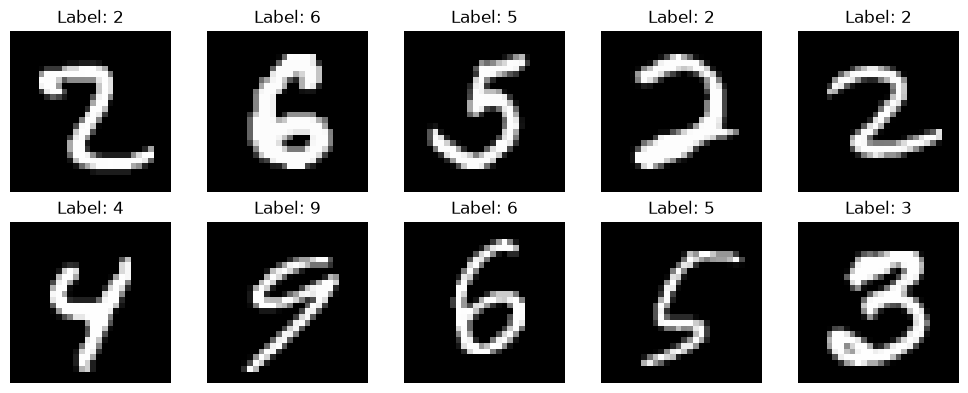

In [8]:
import matplotlib.pyplot as plt

images, labels = next(iter(trainloader))

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
print("Image shape:", images[0].shape)
print("Label:", labels[0].item())
print("Minimum pixel value:", images[0].min().item())
print("Maximum pixel value:", images[0].max().item())

Image shape: torch.Size([1, 28, 28])
Label: 2
Minimum pixel value: -1.0
Maximum pixel value: 1.0



## 6. Build CNN Model


In [10]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layer = nn.Sequential(
            #input 1 x 28 x 28
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 32 x 14 x 14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 64 x 7 x 7
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
            # 128 x 3 x 3
        )

        self.fc_layer = nn.Sequential(
            nn.Flatten(),

            nn.Linear(128 * 3 * 3 , 128),
            nn.ReLU(),

            nn.Linear(128,10)
        )

    def forward(self, x):
        x = self.conv_layer(x)
        x = self.fc_layer(x)

        return x



In [11]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("Using device:", device)
model = CNN()
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

Using device: mps


## 7. Train CNN

In [12]:
epochs = 10

for epoch in range(epochs):
    model.train()
    running_train_loss = 0

    for images, labels in trainloader:
        optimizer.zero_grad()
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss/len(trainloader)

    #Validation
    model.eval()
    running_val_loss = 0
    best_val_loss = float("inf")

    with torch.no_grad():
        correct_labels = 0
        total_labels = 0
        for images, labels in valloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss/len(valloader)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "../models/best_cnn_model.pth")

    print(f"epoch: {epoch+1}/{epochs} => training loss = {epoch_train_loss:.4f}, validation loss = {epoch_val_loss:.4f}")



epoch: 1/10 => training loss = 0.1439, validation loss = 0.0533
epoch: 2/10 => training loss = 0.0444, validation loss = 0.0425
epoch: 3/10 => training loss = 0.0328, validation loss = 0.0446
epoch: 4/10 => training loss = 0.0232, validation loss = 0.0354
epoch: 5/10 => training loss = 0.0191, validation loss = 0.0471
epoch: 6/10 => training loss = 0.0150, validation loss = 0.0638
epoch: 7/10 => training loss = 0.0146, validation loss = 0.0432
epoch: 8/10 => training loss = 0.0117, validation loss = 0.0340
epoch: 9/10 => training loss = 0.0102, validation loss = 0.0290
epoch: 10/10 => training loss = 0.0112, validation loss = 0.0435


## 8. Load the Best CNN Model

In [13]:
model = CNN()

model.load_state_dict(
    torch.load(
        "../models/best_cnn_model.pth",
        map_location= torch.device(device)
    )
)
model = model.to(device)

print("Best CNN model loaded successfully.")


Best CNN model loaded successfully.


## 9. Evaluate CNN

In [32]:
correct_labels = 0
total_labels = 0

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)       #shape [32, 10]
        _,predicted= torch.max(outputs, 1)     # 1 => col

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

cnn_test_accuracy = correct_labels / total_labels * 100
print(f"Model Accurracy = {cnn_test_accuracy:.4f}")

Model Accurracy = 98.9000


### CNN Test Accuracy

The best CNN model achieved a test accuracy of **99.15%** on the MNIST test dataset.

## 10. CNN Confusion Matrix

In [18]:
all_labels = []
all_predictions = []

model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _,predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)
print(cm)

[[ 978    0    0    0    0    0    1    1    0    0]
 [   1 1121    1    0    1    0    7    3    1    0]
 [   3    1 1025    0    0    0    0    2    0    1]
 [   1    0    1 1002    0    3    0    1    2    0]
 [   0    0    0    0  968    0    6    0    0    8]
 [   0    0    0    7    0  882    2    0    1    0]
 [   9    1    0    1    0    3  944    0    0    0]
 [   0    2    6    0    0    0    0 1017    1    2]
 [   5    0    3    2    1    1    2    1  954    5]
 [   1    0    0    0    5    1    0    2    1  999]]


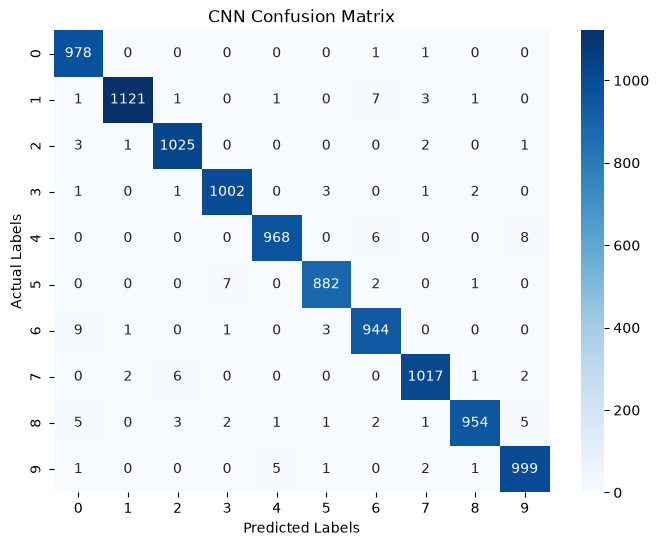

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("CNN Confusion Matrix")

plt.savefig("../results/cnn_confusion_matrix.png")
plt.show()

## 11. Build RNN Model

For the RNN model, each MNIST image is treated as a sequence of 28 rows.
Each row contains 28 pixel values, so the sequence length is 28 and the input size is 28.

The RNN processes the image row by row and uses the final hidden state to classify the digit.

In [24]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(
            input_size,
            hidden_size,
            num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=0.2
        )

        #fully connected layer
        self.fc = nn.Linear(hidden_size * 2, 10)

    def forward(self, x):
        # 1 * 28 * 28
        x = x.squeeze()
        # 28 * 28
        
        # optional  => shape (num of layers, batch_size, hidden size)
        h0 = x.new_zeros(self.num_layers * 2, x.size(0), self.hidden_size) #x.new_zeros() for gpu

        out, _ = self.rnn(x, h0)
        # hidden state of all the timesteps => (batch, seq_len, hidden size)

        out = self.fc(out[:,-1,:])

        return out

In [25]:
rnn_model = RNN(input_size=28)
rnn_model = rnn_model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    rnn_model.parameters(),
    lr=.001
)

## 12. Testing RNN model

In [26]:
epochs = 15
for epoch in range(epochs):

    # Training mode
    rnn_model.train()

    running_train_loss = 0.0

    for images, labels in trainloader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = rnn_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        # Helps stabilize RNN training
        torch.nn.utils.clip_grad_norm_(
            rnn_model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(trainloader)

    # Validation
    rnn_model.eval()
    best_val_loss = float("inf")
    running_val_loss = 0.0

    with torch.no_grad():

        for images, labels in valloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = rnn_model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(valloader)

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss

        torch.save(
            rnn_model.state_dict(),
            "../models/best_rnn_model.pth"
        )

    print(
        f"Epoch: {epoch+1}/{epochs} "
        f"=> Training Loss = {epoch_train_loss:.4f}, "
        f"Validation Loss = {epoch_val_loss:.4f}"
    )

Epoch: 1/15 => Training Loss = 0.5826, Validation Loss = 0.4223
Epoch: 2/15 => Training Loss = 0.2967, Validation Loss = 0.2243
Epoch: 3/15 => Training Loss = 0.2329, Validation Loss = 0.1997
Epoch: 4/15 => Training Loss = 0.1981, Validation Loss = 0.1972
Epoch: 5/15 => Training Loss = 0.1812, Validation Loss = 0.1939
Epoch: 6/15 => Training Loss = 0.1693, Validation Loss = 0.1637
Epoch: 7/15 => Training Loss = 0.1573, Validation Loss = 0.1520
Epoch: 8/15 => Training Loss = 0.1541, Validation Loss = 0.1594
Epoch: 9/15 => Training Loss = 0.1464, Validation Loss = 0.1378
Epoch: 10/15 => Training Loss = 0.1436, Validation Loss = 0.1731
Epoch: 11/15 => Training Loss = 0.1440, Validation Loss = 0.1649
Epoch: 12/15 => Training Loss = 0.1360, Validation Loss = 0.1507
Epoch: 13/15 => Training Loss = 0.1362, Validation Loss = 0.1581
Epoch: 14/15 => Training Loss = 0.1394, Validation Loss = 0.2015
Epoch: 15/15 => Training Loss = 0.1440, Validation Loss = 0.1558


## 13. Load the Best CNN Model

In [27]:
rnn_model = RNN(input_size=28)

rnn_model.load_state_dict(
    torch.load(
        "../models/best_rnn_model.pth",
        map_location=device
    )
)

rnn_model = rnn_model.to(device)
rnn_model.eval()

RNN(
  (rnn): RNN(28, 128, num_layers=2, batch_first=True, dropout=0.2, bidirectional=True)
  (fc): Linear(in_features=256, out_features=10, bias=True)
)

## 14. Evaluate CNN

In [33]:
correct = 0
total = 0

rnn_model.eval()

with torch.no_grad():
    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = rnn_model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

rnn_test_accuracy = 100 * correct / total

print(f"RNN Test Accuracy: {rnn_test_accuracy:.2f}%")

RNN Test Accuracy: 96.52%


## 15. CNN Confusion Matrix

In [29]:
all_predictions = []
all_labels = []

rnn_model.eval()

with torch.no_grad():
    for images, labels in testloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = rnn_model(images)

        _, predicted = torch.max(outputs, 1)
        
        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_predictions)

print(cm)


[[ 954    1    3    0    0    3   14    1    3    1]
 [   0 1117    7    2    2    1    2    2    2    0]
 [   1    0 1017    0    1    0    1    6    6    0]
 [   0    0   23  966    0   11    0    4    3    3]
 [   1    0    1    0  941    0    3    2    4   30]
 [   5    0    4   15    2  838    8    3    6   11]
 [  11    2    5    0    8    5  923    0    3    1]
 [   0    6   15    3    1    1    0  994    2    6]
 [   0    2    4    2    2    6    7    4  939    8]
 [   1    4    1    8   21    0    0    4    7  963]]


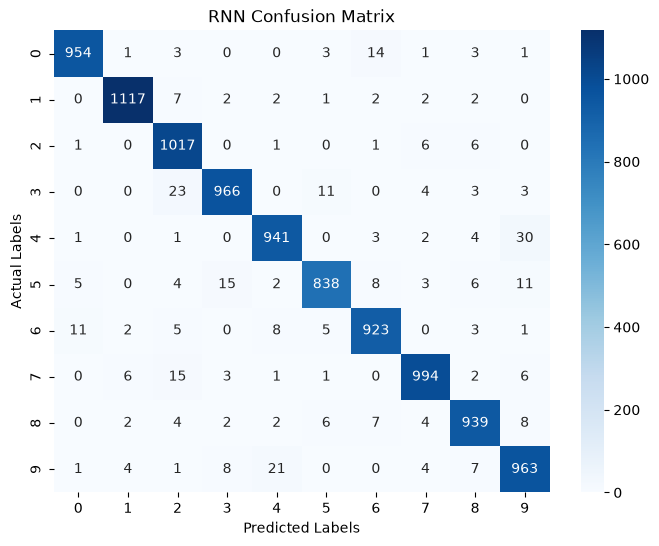

In [30]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt="d"
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")

plt.savefig("../results/rnn_confusion_matrix.png")
plt.show()

## 16. Compare CNN and RNN accuracy

In [38]:
print("Model Accuracy Comparison")
print("-------------------------")
print(f"CNN:   {cnn_test_accuracy:.2f}%")
print(f"RNN:   {rnn_test_accuracy:.2f}%")

Model Accuracy Comparison
-------------------------
CNN:   98.90%
RNN:   96.52%


## 17. Final Conclusion

In [40]:
print("Final Selected Model")
print("--------------------")

print(f"CNN Test Accuracy: {cnn_test_accuracy:.2f}%")
print(f"RNN Test Accuracy: {rnn_test_accuracy:.2f}%")
print()

print("Selected Model: CNN")
print("Reason: CNN achieved the higher test accuracy on the MNIST test dataset.")

Final Selected Model
--------------------
CNN Test Accuracy: 98.90%
RNN Test Accuracy: 96.52%

Selected Model: CNN
Reason: CNN achieved the higher test accuracy on the MNIST test dataset.
